In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from IPython.display import Image, display
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [9]:
class LLMState(TypedDict):
    question: str
    answer: str


In [10]:
load_dotenv()

True

In [11]:
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [12]:

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3-70B-Instruct",
    task="text-generation",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

e:\CV\InfoDevelopers\Internship\LangGraph\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
def llm_qa(state: LLMState) -> LLMState:
    question = state["question"]
    prompt = f"Answer the given question {question}"
    
    answer = model.invoke(prompt).content
    
    state["answer"] = answer
    
    return state

In [14]:
# graph

graph = StateGraph(LLMState)
graph.add_node("llm_qa", llm_qa)

graph.add_edge(START, "llm_qa")
graph.add_edge("llm_qa", END)

workflow = graph.compile()


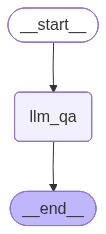

In [15]:
display(Image(workflow.get_graph().draw_mermaid_png()))

In [16]:
inital_state = {'question': 'What is the radius of earth?'}
final_state = workflow.invoke(inital_state)

print(final_state['answer'])

The radius of the Earth is approximately 6,371 kilometers (3,959 miles).
